# HybridBCIModel XAI Analysis
**DeepSHAP (GradientExplainer) + ERD Validation — 52 Subjects (Cho2017 / GigaDB)**

| 항목 | 값 |
|---|---|
| 모델 | HybridBCIModel (EEGNet + BiLSTM + SoftmaxFusion) |
| 데이터 | GigaDB 100295, 52명 LOSO |
| 성능 | 74.2% ± 11.1% |
| 런타임 | T4/A100 GPU 권장 |

**실행 순서:** 위→아래로 순서대로 실행. 각 섹션 독립 실행 불가 (공유 변수 사용)

---
## 0. 환경 설정

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import subprocess, sys
def pip(*pkgs):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *pkgs], check=True)

pip('shap==0.46.0')
print('패키지 설치 완료')

Mounted at /content/drive
패키지 설치 완료


In [3]:
# ────────────────────────────────────────────────────
#  ★ 여기만 수정하세요 ★
DRIVE_ROOT = '/content/drive/MyDrive/BCI_Research'
# ────────────────────────────────────────────────────

from pathlib import Path

ROOT     = Path(DRIVE_ROOT)
DATA_DIR = ROOT / 'preprocessed' / 'member_A'
CKPT_DIR = ROOT / 'results' / 'checkpoints_A'
OUT_SHAP = ROOT / 'results' / 'xai_shap'
OUT_ERD  = ROOT / 'results' / 'xai_erd'

for d in [OUT_SHAP, OUT_ERD,
          OUT_SHAP / 'figures', OUT_ERD / 'figures']:
    d.mkdir(parents=True, exist_ok=True)

h5_files = sorted(DATA_DIR.glob('sub-*.h5'))
pt_files = sorted(CKPT_DIR.glob('best_s*.pt'))
print(f'Data : {DATA_DIR}  존재: {DATA_DIR.exists()}')
print(f'Ckpt : {CKPT_DIR}  존재: {CKPT_DIR.exists()}')
print(f'HDF5 : {len(h5_files)}개  |  Checkpoint: {len(pt_files)}개')

if not h5_files:
    raise FileNotFoundError(f'HDF5 파일 없음: {DATA_DIR}')
if not pt_files:
    raise FileNotFoundError(f'체크포인트 없음: {CKPT_DIR}')

Data : /content/drive/MyDrive/BCI_Research/preprocessed/member_A  존재: True
Ckpt : /content/drive/MyDrive/BCI_Research/results/checkpoints_A  존재: True
HDF5 : 52개  |  Checkpoint: 52개


In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.signal import butter, sosfiltfilt, hilbert, spectrogram
from scipy.stats import wilcoxon
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SIDS   = list(range(1, 53))
FS     = 512
print(f'PyTorch {torch.__version__}  |  Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch 2.11.0+cu128  |  Device: cuda
GPU: Tesla T4


---
## 1. 모델 정의 (공통)

In [5]:
CFG = {
    'n_eeg_ch': 64, 'n_emg_ch': 4, 'n_times': 2304, 'n_classes': 2,
    'emg_ds_factor': 8, 'eegnet_F1': 8, 'eegnet_D': 2, 'eegnet_kern_len': 256,
    'eegnet_dropout': 0.5, 'lstm_hidden': 128, 'lstm_layers': 2,
    'lstm_dropout': 0.3, 'clf_dropout': 0.3, 'feat_dim': 256,
}
CFG['n_times_emg'] = CFG['n_times'] // CFG['emg_ds_factor']

# 64채널 이름 (국제 10-20 확장)
CH_NAMES = [
    'Fp1','AF7','AF3','F1', 'F3', 'F5', 'F7',
    'FT7','FC5','FC3','FC1','FCz','FC2','FC4',
    'FC6','FT8','T7', 'C5', 'C3', 'C1', 'Cz',
    'C2', 'C4', 'C6', 'T8', 'TP7','CP5','CP3',
    'CP1','CPz','CP2','CP4','CP6','TP8',
    'P7', 'P5', 'P3', 'P1', 'Pz', 'P2',
    'P4', 'P6', 'P8', 'PO7','PO3','POz',
    'PO4','PO8','O1', 'Oz', 'O2', 'Iz',
    'Fp2','AF8','AF4','F2', 'F4', 'F6', 'F8',
    'FT9','FT10','TP9','TP10','Fpz',
]
CH_IDX   = {ch: i for i, ch in enumerate(CH_NAMES)}
MOTOR_CHS = {'C3','C1','Cz','C2','C4','FC3','FC1','FCz','FC2','FC4',
             'CP3','CP1','CPz','CP2','CP4'}


class EEGNetEncoder(nn.Module):
    def __init__(self, n_ch, n_times, F1=8, D=2, kern_len=256, dropout=0.5, feat_dim=256):
        super().__init__()
        F2 = F1 * D
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, (1, kern_len), padding=(0, kern_len//2), bias=False),
            nn.BatchNorm2d(F1))
        self.block2 = nn.Sequential(
            nn.Conv2d(F1, F2, (n_ch, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F2), nn.ELU(), nn.AvgPool2d((1, 4)), nn.Dropout(dropout))
        self.block3 = nn.Sequential(
            nn.Conv2d(F2, F2, (1, 16), padding=(0, 8), groups=F2, bias=False),
            nn.Conv2d(F2, F2, 1, bias=False),
            nn.BatchNorm2d(F2), nn.ELU(), nn.AvgPool2d((1, 8)), nn.Dropout(dropout))
        flat = self._flat(n_ch, n_times)
        self.fc = nn.Sequential(nn.Flatten(), nn.Linear(flat, feat_dim), nn.ELU())

    def _flat(self, n_ch, n_times):
        with torch.no_grad():
            x = torch.zeros(1, 1, n_ch, n_times)
            return self.block3(self.block2(self.block1(x))).numel()

    def forward(self, x):
        return self.fc(self.block3(self.block2(self.block1(x.unsqueeze(1)))))


class EMGBiLSTMEncoder(nn.Module):
    def __init__(self, n_ch=4, hidden=128, n_layers=2, dropout=0.3, feat_dim=256):
        super().__init__()
        self.lstm = nn.LSTM(n_ch, hidden, n_layers, batch_first=True, bidirectional=True,
                            dropout=dropout if n_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden * 2)
        self.fc   = nn.Sequential(nn.Linear(hidden * 2, feat_dim), nn.ELU())

    def forward(self, x):
        out, _ = self.lstm(x.permute(0, 2, 1))
        return self.fc(self.norm(out[:, -1, :]))


class SoftmaxAttentionFusion(nn.Module):
    def __init__(self, feat_dim=256):
        super().__init__()
        self.W_eeg = nn.Linear(feat_dim, feat_dim)
        self.W_emg = nn.Linear(feat_dim, feat_dim)
        self.attn  = nn.Linear(feat_dim * 2, 2)

    def forward(self, h_eeg, h_emg):
        w = F.softmax(self.attn(torch.cat([h_eeg, h_emg], dim=-1)), dim=-1)
        return w[:, 0:1]*self.W_eeg(h_eeg) + w[:, 1:2]*self.W_emg(h_emg), w


class HybridBCIModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        fd = cfg['feat_dim']
        self.eeg_enc = EEGNetEncoder(cfg['n_eeg_ch'], cfg['n_times'],
            cfg['eegnet_F1'], cfg['eegnet_D'], cfg['eegnet_kern_len'],
            cfg['eegnet_dropout'], fd)
        self.emg_enc = EMGBiLSTMEncoder(cfg['n_emg_ch'], cfg['lstm_hidden'],
            cfg['lstm_layers'], cfg['lstm_dropout'], fd)
        self.fusion  = SoftmaxAttentionFusion(fd)
        self.clf     = nn.Sequential(nn.Linear(fd, 128), nn.ELU(),
                                     nn.Dropout(cfg['clf_dropout']),
                                     nn.Linear(128, cfg['n_classes']))

    def forward(self, eeg, emg):
        fused, w = self.fusion(self.eeg_enc(eeg), self.emg_enc(emg))
        return self.clf(fused), w


class _LogitOnly(nn.Module):
    """SHAP용 wrapper: logit만 반환"""
    def __init__(self, m):
        super().__init__()
        self.m = m

    def forward(self, eeg, emg):
        return self.m(eeg, emg)[0]


class _LogitClass(nn.Module):
    """SHAP GradientExplainer용 단일-클래스 wrapper.
    SHAP 0.46에서 multi-input(shape 불일치) + multi-output 조합 시
    내부 np.array() 스택 실패를 우회하기 위해 클래스별로 분리 실행."""
    def __init__(self, m, cls_idx):
        super().__init__()
        self.m = m
        self.cls_idx = cls_idx

    def forward(self, eeg, emg):
        return self.m(eeg, emg)[0][:, self.cls_idx:self.cls_idx + 1]


def load_model(sid, device=DEVICE):
    ckpt = CKPT_DIR / f'best_s{sid:02d}.pt'
    m = HybridBCIModel(CFG).to(device)
    m.load_state_dict(torch.load(ckpt, map_location=device, weights_only=True))
    return m


def load_data(sid):
    ds = CFG['emg_ds_factor']
    with h5py.File(DATA_DIR / f'sub-{sid:02d}_member_A.h5', 'r') as f:
        eeg = f['eeg/epochs'][:].astype(np.float32)        # (N, 64, 2304)
        emg = f['emg/epochs'][:, :, ::ds].astype(np.float32)  # (N, 4, T/8)
        lbl = f['labels'][:].astype(np.int64) - 1          # 0-indexed
    return eeg, emg, lbl


# sanity check
_m = load_model(1)
_m.eval()
with torch.no_grad():
    _eeg, _emg, _ = load_data(1)
    _out, _ = _m(torch.tensor(_eeg[:2]).to(DEVICE), torch.tensor(_emg[:2]).to(DEVICE))
print(f'모델 정의 OK  |  C3={CH_IDX["C3"]}  C4={CH_IDX["C4"]}')
print(f'출력 shape: {_out.shape}  softmax: {F.softmax(_out, -1)[0].cpu().numpy().round(3)}')
del _m, _eeg, _emg, _out

모델 정의 OK  |  C3=18  C4=22
출력 shape: torch.Size([2, 2])  softmax: [0.404 0.596]


---
## 2. DeepSHAP — 52명 Feature Importance

`shap.GradientExplainer` 사용.  
**BiLSTM cuDNN 이슈**: cuDNN RNN은 이중 역전파(double-backward)를 지원하지 않아  
`torch.backends.cudnn.enabled = False` 로 일시 비활성화 후 SHAP 계산.

- Background: 피험자별 100샘플 (50 Left + 50 Right)  
- Test: background 제외 최대 200샘플  
- 예상 시간: T4 기준 피험자당 ~3분 → 52명 약 150분

In [6]:
import shap
print(f'shap {shap.__version__}')

N_BG   = 100   # background 샘플
N_TEST = 200   # test 샘플
FORCE_RECOMPUTE = False  # True 로 바꾸면 캐시 무시하고 전부 재계산

CACHE_DIR = OUT_SHAP / 'cache'
CACHE_DIR.mkdir(parents=True, exist_ok=True)

shap_records = []
failed_sids  = []

for sid in SIDS:
    h5_path   = DATA_DIR / f'sub-{sid:02d}_member_A.h5'
    ckpt_path = CKPT_DIR / f'best_s{sid:02d}.pt'
    cache_path = CACHE_DIR / f'shap_s{sid:02d}.npz'

    if not h5_path.exists() or not ckpt_path.exists():
        print(f'[s{sid:02d}] 파일 없음 — 건너뜀')
        failed_sids.append(sid)
        continue

    # ── 캐시 로드 ──────────────────────────────────────
    if cache_path.exists() and not FORCE_RECOMPUTE:
        d = np.load(cache_path)
        shap_records.append({
            'sid':     sid,
            'eeg_imp': d['eeg_imp'],
            'emg_imp': d['emg_imp'],
            'acc':     float(d['acc']),
        })
        top_ch = CH_NAMES[d['eeg_imp'].mean(0).argmax()]
        print(f'[s{sid:02d}] ↩ 캐시 로드  acc={float(d["acc"]):.3f}  top_EEG={top_ch}')
        continue

    # ── SHAP 계산 ──────────────────────────────────────
    try:
        eeg, emg, lbl = load_data(sid)
        model   = load_model(sid)
        wrapper = _LogitOnly(model)

        rng  = np.random.RandomState(42 + sid)
        idx0 = np.where(lbl == 0)[0]
        idx1 = np.where(lbl == 1)[0]

        n_bg0 = min(N_BG // 2, len(idx0))
        n_bg1 = min(N_BG // 2, len(idx1))
        bg_idx = np.concatenate([rng.choice(idx0, n_bg0, replace=False),
                                  rng.choice(idx1, n_bg1, replace=False)])

        all_idx = rng.permutation(len(lbl))
        te_idx  = np.setdiff1d(all_idx, bg_idx)[:N_TEST]

        bg_eeg = torch.tensor(eeg[bg_idx], device=DEVICE)
        bg_emg = torch.tensor(emg[bg_idx], device=DEVICE)
        te_eeg = torch.tensor(eeg[te_idx], device=DEVICE)
        te_emg = torch.tensor(emg[te_idx], device=DEVICE)

        # SHAP 0.46에서 multi-input(EEG/EMG shape 불일치) + multi-output 조합 시
        # 내부 np.array() 스택 오류 발생 → 클래스별 단일-출력 wrapper로 분리 실행
        prev_cudnn = torch.backends.cudnn.enabled
        torch.backends.cudnn.enabled = False
        try:
            sv_list = []
            for cls_idx in range(2):
                w_cls = _LogitClass(model, cls_idx)
                w_cls.train()
                exp = shap.GradientExplainer(w_cls, [bg_eeg, bg_emg])
                sv_cls = exp.shap_values([te_eeg, te_emg], nsamples=50)
                # SHAP 0.46: 단일 출력 모델도 trailing class dim 1을 붙이는 경우 있음
                # e.g. eeg sv: (N,64,2304,1) → (N,64,2304)
                sv_cls_clean = [
                    s[..., 0] if s.ndim == inputs.ndim + 1 else s
                    for s, inputs in zip(sv_cls, [te_eeg.cpu().numpy(), te_emg.cpu().numpy()])
                ]
                sv_list.append(sv_cls_clean)
        finally:
            torch.backends.cudnn.enabled = prev_cudnn
        model.eval()

        # sv_list[cls][input_idx]: (N_TEST, *input_shape)
        eeg_imp = np.stack([np.abs(sv_list[c][0]).mean((0, 2)) for c in range(2)])  # (2, 64)
        emg_imp = np.stack([np.abs(sv_list[c][1]).mean((0, 2)) for c in range(2)])  # (2, 4)

        with torch.no_grad():
            logits = wrapper(te_eeg, te_emg).cpu().numpy()
        acc = float((logits.argmax(1) == lbl[te_idx]).mean())

        # 캐시 저장
        np.savez_compressed(cache_path, eeg_imp=eeg_imp, emg_imp=emg_imp, acc=np.float32(acc))

        shap_records.append({
            'sid': sid, 'eeg_imp': eeg_imp,
            'emg_imp': emg_imp, 'acc': acc,
        })
        top_ch = CH_NAMES[eeg_imp.mean(0).argmax()]
        print(f'[s{sid:02d}] ✓  acc={acc:.3f}  top_EEG={top_ch}')

    except Exception as e:
        print(f'[s{sid:02d}] ✗  {type(e).__name__}: {e}')
        failed_sids.append(sid)
    finally:
        try:
            del model, wrapper, bg_eeg, bg_emg, te_eeg, te_emg
        except Exception:
            pass
        if DEVICE.type == 'cuda':
            torch.cuda.empty_cache()

n_cached  = sum(1 for r in shap_records if (CACHE_DIR / f'shap_s{r["sid"]:02d}.npz').exists())
print(f'\n완료: {len(shap_records)}/52  실패: {failed_sids if failed_sids else "없음"}')
print(f'캐시 위치: {CACHE_DIR}  ({n_cached}개 저장됨)')

shap 0.46.0
[s01] ↩ 캐시 로드  acc=0.590  top_EEG=Oz
[s02] ↩ 캐시 로드  acc=0.600  top_EEG=Oz
[s03] ↩ 캐시 로드  acc=0.990  top_EEG=Oz
[s04] ↩ 캐시 로드  acc=0.880  top_EEG=Oz
[s05] ↩ 캐시 로드  acc=0.700  top_EEG=Oz
[s06] ↩ 캐시 로드  acc=0.850  top_EEG=Oz
[s07] ↩ 캐시 로드  acc=0.621  top_EEG=Oz
[s08] ↩ 캐시 로드  acc=0.640  top_EEG=Oz
[s09] ↩ 캐시 로드  acc=0.779  top_EEG=AF4
[s10] ↩ 캐시 로드  acc=0.850  top_EEG=Oz
[s11] ↩ 캐시 로드  acc=0.650  top_EEG=Oz
[s12] ↩ 캐시 로드  acc=0.710  top_EEG=Oz
[s13] ↩ 캐시 로드  acc=0.680  top_EEG=P6
[s14] ↩ 캐시 로드  acc=0.970  top_EEG=FC2
[s15] ↩ 캐시 로드  acc=0.780  top_EEG=Oz
[s16] ↩ 캐시 로드  acc=0.770  top_EEG=Oz
[s17] ↩ 캐시 로드  acc=0.620  top_EEG=Oz
[s18] ↩ 캐시 로드  acc=0.730  top_EEG=P6
[s19] ↩ 캐시 로드  acc=0.850  top_EEG=AF7
[s20] ↩ 캐시 로드  acc=0.840  top_EEG=Oz
[s21] ↩ 캐시 로드  acc=0.800  top_EEG=Oz
[s22] ↩ 캐시 로드  acc=0.870  top_EEG=Oz
[s23] ↩ 캐시 로드  acc=0.900  top_EEG=Oz
[s24] ↩ 캐시 로드  acc=0.750  top_EEG=AF4
[s25] ↩ 캐시 로드  acc=0.750  top_EEG=Oz
[s26] ↩ 캐시 로드  acc=0.750  top_EEG=FC2
[s27] ↩ 캐시 로드  acc=0.

In [7]:
if not shap_records:
    raise RuntimeError(
        'shap_records가 비어 있습니다.\n'
        '위 셀(shap_run)의 ✗ 줄에서 실제 예외 메시지를 확인하세요.\n'
        f'실패 피험자: {failed_sids}'
    )

n_shap   = len(shap_records)
eeg_all  = np.stack([r['eeg_imp'] for r in shap_records])  # (S, 2, 64)
emg_all  = np.stack([r['emg_imp'] for r in shap_records])  # (S, 2, 4)
eeg_mean = eeg_all.mean(0)   # (2, 64)
eeg_std  = eeg_all.std(0)
emg_mean = emg_all.mean(0)   # (2, 4)
emg_std  = emg_all.std(0)

np.savez_compressed(
    OUT_SHAP / 'shap_channel_importance.npz',
    eeg_mean=eeg_mean, eeg_std=eeg_std,
    emg_mean=emg_mean, emg_std=emg_std,
    ch_names=np.array(CH_NAMES),
    sids=np.array([r['sid'] for r in shap_records]),
    accs=np.array([r['acc'] for r in shap_records]),
)

# per-subject CSV
EMG_NAMES = ['EMG1', 'EMG2', 'EMG3', 'EMG4']
rows = []
for r in shap_records:
    for c, cls in enumerate(['Left_MI', 'Right_MI']):
        top5 = np.argsort(r['eeg_imp'][c])[::-1][:5]
        rows.append({
            'sid': r['sid'], 'class': cls, 'acc': round(r['acc'], 4),
            **{f'top{k+1}_eeg': CH_NAMES[i] for k, i in enumerate(top5)},
            'c3_shap': round(float(r['eeg_imp'][c][CH_IDX['C3']]), 6),
            'c4_shap': round(float(r['eeg_imp'][c][CH_IDX['C4']]), 6),
            **{f'{EMG_NAMES[j]}_shap': round(float(r['emg_imp'][c][j]), 6)
               for j in range(4)},
        })
pd.DataFrame(rows).to_csv(OUT_SHAP / 'shap_per_subject.csv', index=False)

print(f'저장 완료 ({n_shap}명)')
c3i, czi, c4i = CH_IDX['C3'], CH_IDX['Cz'], CH_IDX['C4']
for c, cls in enumerate(['Left MI', 'Right MI']):
    top5 = [CH_NAMES[i] for i in np.argsort(eeg_mean[c])[::-1][:5]]
    print(f'[{cls}] Top-5: {top5}')
    print(f'  C3={eeg_mean[c][c3i]:.4f}  Cz={eeg_mean[c][czi]:.4f}  C4={eeg_mean[c][c4i]:.4f}')

저장 완료 (52명)
[Left MI] Top-5: ['Oz', 'FC2', 'AF4', 'FCz', 'P6']
  C3=0.0005  Cz=0.0003  C4=0.0004
[Right MI] Top-5: ['Oz', 'FC2', 'AF4', 'FCz', 'P6']
  C3=0.0005  Cz=0.0003  C4=0.0004


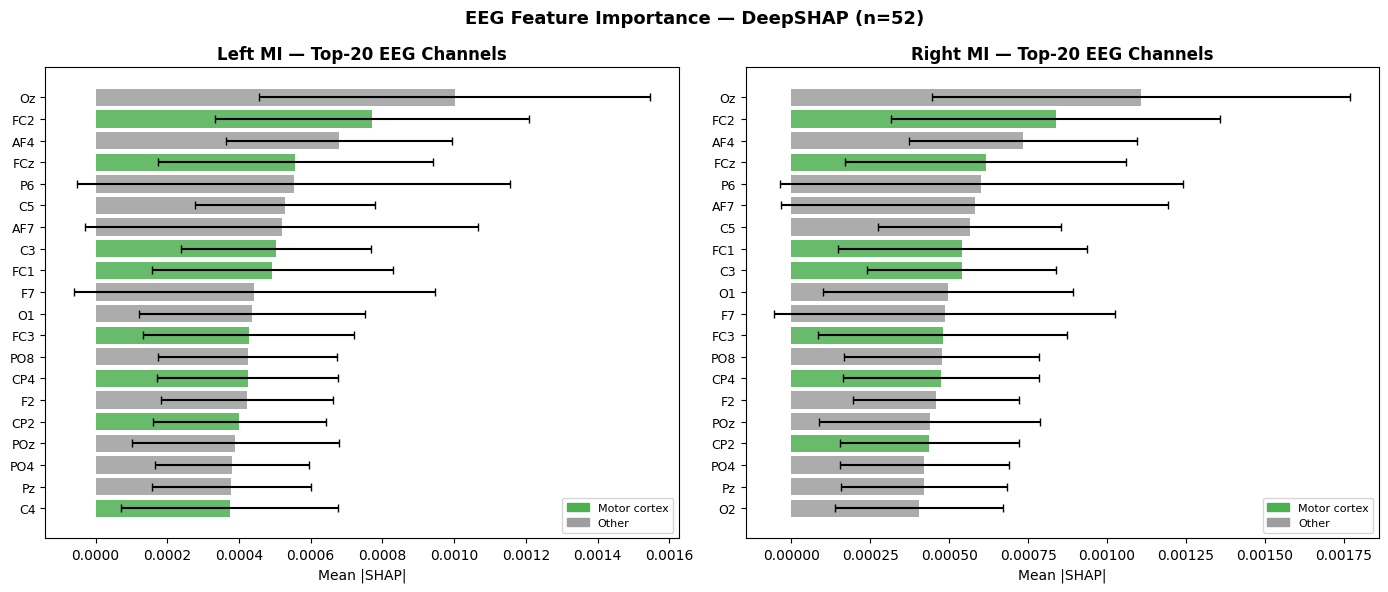

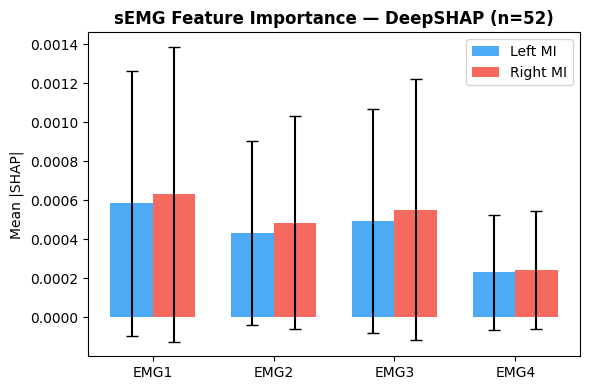

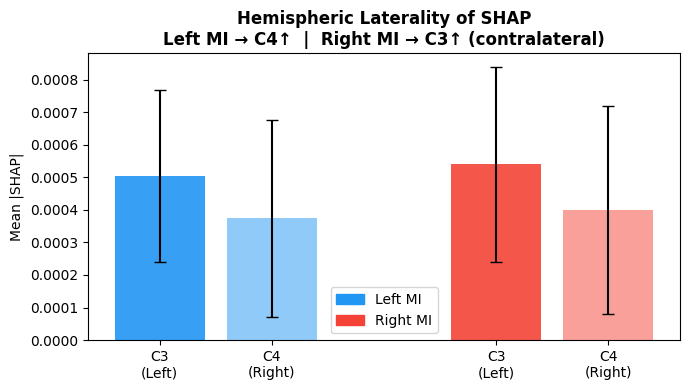

SHAP 피규어 저장 완료


In [8]:
EMG_NAMES = ['EMG1', 'EMG2', 'EMG3', 'EMG4']
c3i, czi, c4i = CH_IDX['C3'], CH_IDX['Cz'], CH_IDX['C4']

# ── Figure A: Top-20 EEG 채널 중요도
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for c, (ax, cls) in enumerate(zip(axes, ['Left MI', 'Right MI'])):
    idx   = np.argsort(eeg_mean[c])[::-1][:20]
    color = ['#4CAF50' if CH_NAMES[i] in MOTOR_CHS else '#9E9E9E' for i in idx]
    ax.barh(range(20), eeg_mean[c][idx][::-1],
            xerr=eeg_std[c][idx][::-1],
            color=color[::-1], alpha=0.85, ecolor='black', capsize=3)
    ax.set_yticks(range(20))
    ax.set_yticklabels([CH_NAMES[i] for i in idx][::-1], fontsize=9)
    ax.set_xlabel('Mean |SHAP|')
    ax.set_title(f'{cls} — Top-20 EEG Channels', fontweight='bold')
    ax.legend(handles=[Patch(color='#4CAF50', label='Motor cortex'),
                        Patch(color='#9E9E9E', label='Other')], fontsize=8)
fig.suptitle(f'EEG Feature Importance — DeepSHAP (n={n_shap})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(OUT_SHAP / 'figures' / 'fig_eeg_shap_bar.png', dpi=300, bbox_inches='tight')
fig.savefig(OUT_SHAP / 'figures' / 'fig_eeg_shap_bar.pdf', bbox_inches='tight')
plt.show()

# ── Figure B: sEMG 채널 중요도
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(4); w = 0.35
for c, (cls, col) in enumerate(zip(['Left MI', 'Right MI'], ['#2196F3', '#F44336'])):
    ax.bar(x + c*w, emg_mean[c], w, yerr=emg_std[c],
           label=cls, color=col, alpha=0.8, ecolor='black', capsize=4)
ax.set_xticks(x + w/2)
ax.set_xticklabels(EMG_NAMES)
ax.set_ylabel('Mean |SHAP|')
ax.legend()
ax.set_title(f'sEMG Feature Importance — DeepSHAP (n={n_shap})', fontweight='bold')
plt.tight_layout()
fig.savefig(OUT_SHAP / 'figures' / 'fig_emg_shap.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Figure C: C3 / C4 반구 편재화 (막대별 개별 alpha)
fig, ax = plt.subplots(figsize=(7, 4))
for c, (cls, col) in enumerate(zip(['Left MI', 'Right MI'], ['#2196F3', '#F44336'])):
    ax.bar([c*3],     [eeg_mean[c][c3i]], yerr=[eeg_std[c][c3i]],
           color=col, alpha=0.9, ecolor='black', capsize=4)
    ax.bar([c*3 + 1], [eeg_mean[c][c4i]], yerr=[eeg_std[c][c4i]],
           color=col, alpha=0.5, ecolor='black', capsize=4)
ax.set_xticks([0, 1, 3, 4])
ax.set_xticklabels(['C3\n(Left)', 'C4\n(Right)', 'C3\n(Left)', 'C4\n(Right)'])
ax.set_ylabel('Mean |SHAP|')
ax.set_title('Hemispheric Laterality of SHAP\nLeft MI → C4↑  |  Right MI → C3↑ (contralateral)',
             fontweight='bold')
ax.legend(handles=[Patch(color='#2196F3', label='Left MI'),
                    Patch(color='#F44336', label='Right MI')])
plt.tight_layout()
fig.savefig(OUT_SHAP / 'figures' / 'fig_laterality.png', dpi=300, bbox_inches='tight')
plt.show()
print('SHAP 피규어 저장 완료')

---
## 3. ERD Validation — Alpha/Beta Band Desynchronization

**ERD(t) = 10·log₁₀[P(t) / P_baseline]  (dB)**  
음수 dB = 탈동기화 → Motor Imagery 중 정상 반응

HDF5에 `eeg/mu_epochs` / `eeg/beta_epochs` 키가 있으면 사용,  
없으면 `eeg/epochs`에서 scipy Butterworth 밴드패스 필터링 적용.

In [9]:
TMIN, TMAX = -0.5, 4.0
N_T = 2304
T   = np.linspace(TMIN, TMAX, N_T)
BL_MASK = (T >= -0.5) & (T < 0.0)   # 기저선: -0.5 ~ 0 s
MI_MASK = (T >= 0.5)  & (T < 3.0)   # 평가창:  0.5 ~ 3.0 s

c3i, czi, c4i = CH_IDX['C3'], CH_IDX['Cz'], CH_IDX['C4']


def bandpass(data, lo, hi, fs=FS, order=4):
    """data: (..., T)  반환: 같은 shape"""
    sos = butter(order, [lo, hi], btype='bandpass', fs=fs, output='sos')
    return sosfiltfilt(sos, data, axis=-1).astype(np.float32)


def load_band_epochs(sid):
    """mu/beta 에포크 로드. HDF5에 없으면 인라인 필터링."""
    with h5py.File(DATA_DIR / f'sub-{sid:02d}_member_A.h5', 'r') as f:
        keys = list(f['eeg'].keys())
        lbl  = f['labels'][:].astype(np.int64) - 1

        if 'mu_epochs' in keys and 'beta_epochs' in keys:
            mu   = f['eeg/mu_epochs'][:].astype(np.float32)
            beta = f['eeg/beta_epochs'][:].astype(np.float32)
        else:
            raw  = f['eeg/epochs'][:].astype(np.float32)   # (N, 64, T)
            mu   = bandpass(raw,  8, 12)
            beta = bandpass(raw, 13, 30)
    return mu, beta, lbl


def compute_erd(sig, bl_mask):
    """ERD (dB)  입력: (N, ch, T)  출력: (ch, T)"""
    p   = np.abs(hilbert(sig, axis=-1))**2
    pbl = p[:, :, bl_mask].mean(-1, keepdims=True)
    return (10 * np.log10(p / (pbl + 1e-12))).mean(0)


erd_records = []
for sid in SIDS:
    h5 = DATA_DIR / f'sub-{sid:02d}_member_A.h5'
    if not h5.exists():
        continue
    try:
        mu, beta, lbl = load_band_epochs(sid)
        il = np.where(lbl == 0)[0]
        ir = np.where(lbl == 1)[0]
        erd_records.append({
            'sid':    sid,
            'mu_l':   compute_erd(mu[il],   BL_MASK),
            'mu_r':   compute_erd(mu[ir],   BL_MASK),
            'beta_l': compute_erd(beta[il], BL_MASK),
            'beta_r': compute_erd(beta[ir], BL_MASK),
        })
    except Exception as e:
        print(f'[s{sid:02d}] ✗ {type(e).__name__}: {e}')

n_erd = len(erd_records)
print(f'ERD 계산 완료: {n_erd}명')


def grp_stat(key):
    mat = np.stack([r[key] for r in erd_records])  # (S, 64, T)
    return mat.mean(0), mat.std(0) / np.sqrt(n_erd)

GRP = {k: grp_stat(k) for k in ['mu_l', 'mu_r', 'beta_l', 'beta_r']}

# 핵심 채널 리포트
print(f'\n채널별 평균 ERD dB (MI window 0.5–3.0 s):')
print(f'{"":12s}  {"Left MI":>10}  {"Right MI":>10}')
for ch, idx in [('C3', c3i), ('Cz', czi), ('C4', c4i)]:
    for band, lk, rk in [('Mu',   'mu_l', 'mu_r'),
                           ('Beta', 'beta_l', 'beta_r')]:
        l = GRP[lk][0][idx, MI_MASK].mean()
        r = GRP[rk][0][idx, MI_MASK].mean()
        print(f'  {ch} {band:4s}:  {l:+.2f} dB     {r:+.2f} dB')

ERD 계산 완료: 52명

채널별 평균 ERD dB (MI window 0.5–3.0 s):
                 Left MI    Right MI
  C3 Mu  :  -3.43 dB     -3.89 dB
  C3 Beta:  -3.17 dB     -3.33 dB
  Cz Mu  :  -2.54 dB     -2.69 dB
  Cz Beta:  -2.74 dB     -2.91 dB
  C4 Mu  :  -2.88 dB     -3.26 dB
  C4 Beta:  -2.82 dB     -3.06 dB


In [10]:
# Wilcoxon 검정: ERD < 0 dB (단측)
stat_rows = []
for ch, idx in [('C3', c3i), ('C4', c4i), ('Cz', czi)]:
    for band, lk, rk in [('mu', 'mu_l', 'mu_r'), ('beta', 'beta_l', 'beta_r')]:
        for cls, key in [('left', lk), ('right', rk)]:
            vals = np.array([r[key][idx, MI_MASK].mean() for r in erd_records])
            try:
                _, p = wilcoxon(vals, alternative='less')
            except Exception:
                p = np.nan
            sig = '***' if p < .001 else ('**' if p < .01 else ('*' if p < .05 else 'ns'))
            stat_rows.append({
                'channel': ch, 'band': band, 'class': cls,
                'mean_erd': round(vals.mean(), 3),
                'sd':       round(vals.std(), 3),
                'p':        round(float(p), 4),
                'sig':      sig, 'n': n_erd,
            })

sig_df = pd.DataFrame(stat_rows)
sig_df.to_csv(OUT_ERD / 'erd_significance.csv', index=False)

# Laterality Index = ERD_contralateral − ERD_ipsilateral
lat_rows = []
for r in erd_records:
    for band, lk, rk in [('mu', 'mu_l', 'mu_r'), ('beta', 'beta_l', 'beta_r')]:
        lat_rows.append({
            'sid': r['sid'], 'band': band,
            # Left MI: C4 is contralateral
            'LI_left':  float(r[lk][c4i, MI_MASK].mean() - r[lk][c3i, MI_MASK].mean()),
            # Right MI: C3 is contralateral
            'LI_right': float(r[rk][c3i, MI_MASK].mean() - r[rk][c4i, MI_MASK].mean()),
        })
lat_df = pd.DataFrame(lat_rows)
lat_df.to_csv(OUT_ERD / 'erd_laterality.csv', index=False)

print('=== Wilcoxon (C3 / C4 ERD < 0 dB) ===')
motor_rows = sig_df[sig_df['channel'].isin(['C3', 'C4'])]
print(motor_rows[['channel', 'band', 'class', 'mean_erd', 'sd', 'p', 'sig']].to_string(index=False))

print('\n=== Laterality Index (ERD_contra − ERD_ipsi) ===')
for band in ['mu', 'beta']:
    d = lat_df[lat_df['band'] == band]
    for k, cls in [('LI_left', 'Left MI'), ('LI_right', 'Right MI')]:
        v = d[k].values
        if len(v) > 1:
            _, p = wilcoxon(v, alternative='less')
            sig = '***' if p < .001 else ('**' if p < .01 else ('*' if p < .05 else 'ns'))
        else:
            sig = 'n/a'
        print(f'  {band:4s} {cls}: LI={v.mean():+.2f} ± {v.std():.2f} dB  {sig}')

=== Wilcoxon (C3 / C4 ERD < 0 dB) ===
channel band class  mean_erd    sd   p sig
     C3   mu  left    -3.435 2.537 0.0 ***
     C3   mu right    -3.891 2.588 0.0 ***
     C3 beta  left    -3.173 0.863 0.0 ***
     C3 beta right    -3.331 0.998 0.0 ***
     C4   mu  left    -2.882 2.245 0.0 ***
     C4   mu right    -3.264 2.238 0.0 ***
     C4 beta  left    -2.824 0.819 0.0 ***
     C4 beta right    -3.056 0.870 0.0 ***

=== Laterality Index (ERD_contra − ERD_ipsi) ===
  mu   Left MI: LI=+0.55 ± 1.65 dB  ns
  mu   Right MI: LI=-0.63 ± 1.66 dB  **
  beta Left MI: LI=+0.35 ± 0.59 dB  ns
  beta Right MI: LI=-0.28 ± 0.61 dB  ***


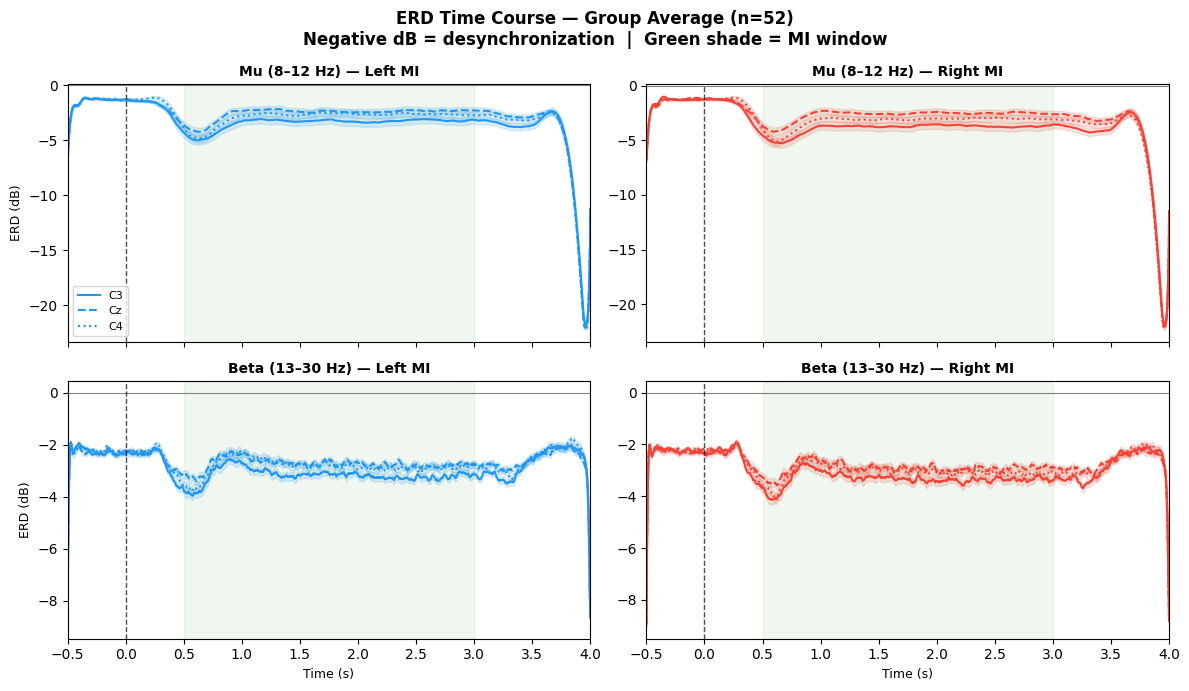

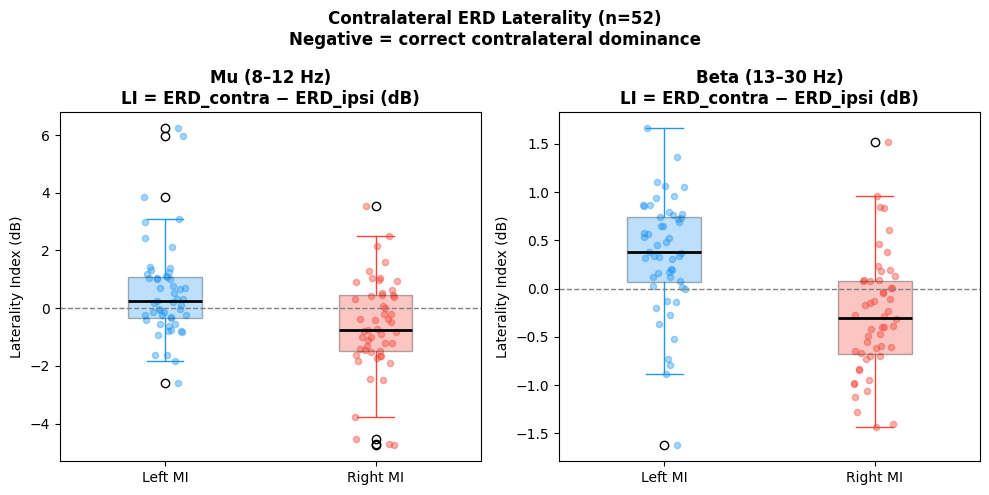

ERD 피규어 저장 완료


In [11]:
# ── Figure A: ERD 시간 경과 (C3, Cz, C4)
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
styles = {'C3': '-', 'Cz': '--', 'C4': ':'}
for row, (band_lbl, lk, rk) in enumerate([
        ('Mu (8–12 Hz)',   'mu_l',   'mu_r'),
        ('Beta (13–30 Hz)','beta_l', 'beta_r')]):
    for col, (cls, key, color) in enumerate([
            ('Left MI',  lk, '#2196F3'),
            ('Right MI', rk, '#F44336')]):
        ax = axes[row, col]
        m_all, s_all = GRP[key]
        for ch, st in styles.items():
            m = m_all[CH_IDX[ch]]
            s = s_all[CH_IDX[ch]]
            ax.plot(T, m, st, color=color, lw=1.5, label=ch)
            ax.fill_between(T, m - s, m + s, color=color, alpha=0.15)
        ax.axhline(0, color='gray', lw=0.8)
        ax.axvline(0, color='black', lw=1.0, ls='--', alpha=0.7)
        ax.axvspan(0.5, 3.0, alpha=0.06, color='green')
        ax.set_xlim(TMIN, TMAX)
        ax.set_title(f'{band_lbl} — {cls}', fontweight='bold', fontsize=10)
        if col == 0:
            ax.set_ylabel('ERD (dB)', fontsize=9)
        if row == 1:
            ax.set_xlabel('Time (s)', fontsize=9)
        if row == 0 and col == 0:
            ax.legend(fontsize=8)

fig.suptitle(f'ERD Time Course — Group Average (n={n_erd})\n'
             'Negative dB = desynchronization  |  Green shade = MI window',
             fontsize=12, fontweight='bold')
plt.tight_layout()
fig.savefig(OUT_ERD / 'figures' / 'fig_erd_timecourse.png', dpi=300, bbox_inches='tight')
fig.savefig(OUT_ERD / 'figures' / 'fig_erd_timecourse.pdf', bbox_inches='tight')
plt.show()

# ── Figure B: Laterality box plot
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, band in zip(axes, ['mu', 'beta']):
    db = lat_df[lat_df['band'] == band]
    for i, (k, cls, col) in enumerate([
            ('LI_left',  'Left MI',  '#2196F3'),
            ('LI_right', 'Right MI', '#F44336')]):
        v = db[k].values
        rng_x = np.random.default_rng(0).uniform(-0.1, 0.1, len(v))
        ax.scatter(np.full(len(v), i) + rng_x, v, alpha=0.4, s=20, color=col)
        bp = ax.boxplot(v, positions=[i], widths=0.35, patch_artist=True,
                        boxprops=dict(facecolor=col, alpha=0.3),
                        medianprops=dict(color='black', linewidth=2),
                        whiskerprops=dict(color=col),
                        capprops=dict(color=col))
    ax.axhline(0, color='gray', lw=1, ls='--')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Left MI', 'Right MI'], fontsize=10)
    band_lbl = 'Mu (8–12 Hz)' if band == 'mu' else 'Beta (13–30 Hz)'
    ax.set_title(f'{band_lbl}\nLI = ERD_contra − ERD_ipsi (dB)', fontweight='bold')
    ax.set_ylabel('Laterality Index (dB)')

fig.suptitle(f'Contralateral ERD Laterality (n={n_erd})\n'
             'Negative = correct contralateral dominance',
             fontsize=12, fontweight='bold')
plt.tight_layout()
fig.savefig(OUT_ERD / 'figures' / 'fig_erd_laterality.png', dpi=300, bbox_inches='tight')
plt.show()
print('ERD 피규어 저장 완료')

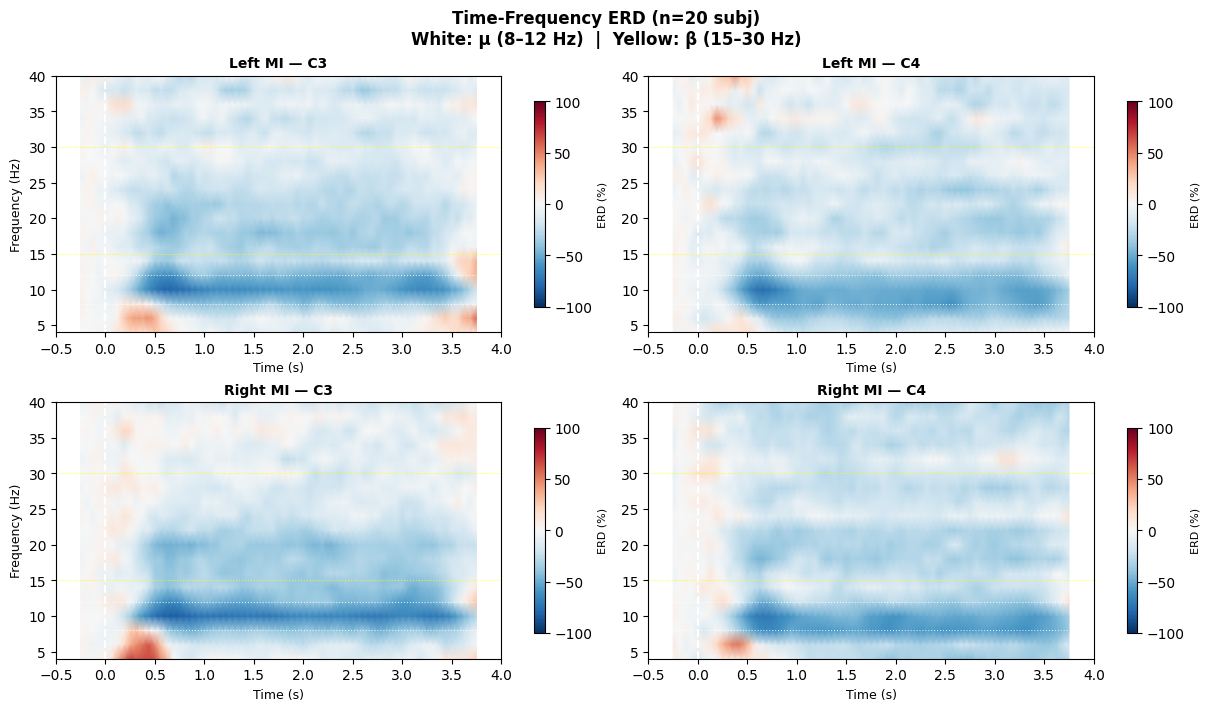

스펙트로그램 저장 완료


In [12]:
# ── Figure C: STFT 시간-주파수 스펙트로그램 (C3, C4)
MAX_TF_SUBS = 20  # 메모리 절약

raw_l, raw_r = [], []
for r in erd_records[:MAX_TF_SUBS]:
    with h5py.File(DATA_DIR / f'sub-{r["sid"]:02d}_member_A.h5', 'r') as f:
        raw = f['eeg/epochs'][:].astype(np.float32)
        lbl = f['labels'][:].astype(np.int64) - 1
    raw_l.append(raw[lbl == 0])
    raw_r.append(raw[lbl == 1])


def tf_erd(trials_ch):
    """trials_ch: (N, T)  한 채널의 ERD(%)  반환: freqs, t_axis, ERD_TF"""
    stacks = []
    for tr in trials_ch:
        f, t, S = spectrogram(tr, fs=FS, nperseg=256, noverlap=224, scaling='density')
        stacks.append(S)
    S_mean = np.stack(stacks).mean(0)                          # (freq, t)
    bl_end = abs(TMIN)
    bl_mask = t < bl_end
    pbl = S_mean[:, bl_mask].mean(-1, keepdims=True) if bl_mask.any() else S_mean[:, :1]
    return f, t + TMIN, (S_mean - pbl) / (pbl + 1e-12) * 100  # ERD %


fig, axes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)
for row, (cls, raw_list) in enumerate([('Left MI', raw_l), ('Right MI', raw_r)]):
    for col, (ch, idx) in enumerate([('C3', c3i), ('C4', c4i)]):
        trials = np.concatenate([r[:, idx, :] for r in raw_list])
        rng = np.random.default_rng(42)
        if len(trials) > 300:
            trials = trials[rng.choice(len(trials), 300, replace=False)]

        freqs, times, erd_tf = tf_erd(trials)
        fm = (freqs >= 4) & (freqs <= 40)
        ax = axes[row, col]
        im = ax.pcolormesh(times, freqs[fm], erd_tf[fm],
                           cmap='RdBu_r', vmin=-100, vmax=100, shading='gouraud')
        ax.axvline(0, color='white', lw=1.5, ls='--')
        for hz, col2 in [(8, 'white'), (12, 'white'), (15, 'yellow'), (30, 'yellow')]:
            ax.axhline(hz, color=col2, lw=0.8, ls=':', alpha=0.8)
        ax.set_xlim(TMIN, TMAX)
        ax.set_ylim(4, 40)
        ax.set_title(f'{cls} — {ch}', fontweight='bold', fontsize=10)
        ax.set_xlabel('Time (s)', fontsize=9)
        if col == 0:
            ax.set_ylabel('Frequency (Hz)', fontsize=9)
        plt.colorbar(im, ax=ax, shrink=0.8).set_label('ERD (%)', fontsize=8)

fig.suptitle(f'Time-Frequency ERD (n={MAX_TF_SUBS} subj)\n'
             'White: μ (8–12 Hz)  |  Yellow: β (15–30 Hz)',
             fontsize=12, fontweight='bold')
fig.savefig(OUT_ERD / 'figures' / 'fig_erd_spectrogram.png', dpi=300, bbox_inches='tight')
fig.savefig(OUT_ERD / 'figures' / 'fig_erd_spectrogram.pdf', bbox_inches='tight')
plt.show()
print('스펙트로그램 저장 완료')

---
## 5. 결과 요약

In [13]:
print('=' * 65)
print('  XAI Analysis 결과 요약')
print('=' * 65)

# SHAP
if shap_records:
    print(f'\n[1] DeepSHAP — {n_shap}명 완료  (실패: {failed_sids if failed_sids else "없음"})')
    for c, cls in enumerate(['Left MI', 'Right MI']):
        top3 = [CH_NAMES[i] for i in np.argsort(eeg_mean[c])[::-1][:3]]
        print(f'   {cls}: Top-3 EEG = {top3}')
        print(f'      C3={eeg_mean[c][c3i]:.4f}  Cz={eeg_mean[c][czi]:.4f}  C4={eeg_mean[c][c4i]:.4f}')
else:
    print('\n[1] DeepSHAP — 실행 안 됨')

# ERD
print(f'\n[2] ERD Validation — {n_erd}명 완료')
motor_stat = sig_df[sig_df['channel'].isin(['C3', 'C4'])]
print(motor_stat[['channel', 'band', 'class', 'mean_erd', 'sd', 'p', 'sig']].to_string(index=False))

print('\n[3] Laterality Index (ERD_contra − ERD_ipsi)')
for band in ['mu', 'beta']:
    d = lat_df[lat_df['band'] == band]
    for k, cls in [('LI_left', 'Left MI'), ('LI_right', 'Right MI')]:
        v = d[k].values
        print(f'   {band:4s} {cls}: {v.mean():+.2f} ± {v.std():.2f} dB')

print('\n[4] 저장 위치')
print(f'   SHAP: {OUT_SHAP}')
print(f'   ERD:  {OUT_ERD}')
print('=' * 65)

  XAI Analysis 결과 요약

[1] DeepSHAP — 52명 완료  (실패: 없음)
   Left MI: Top-3 EEG = ['Oz', 'FC2', 'AF4']
      C3=0.0005  Cz=0.0003  C4=0.0004
   Right MI: Top-3 EEG = ['Oz', 'FC2', 'AF4']
      C3=0.0005  Cz=0.0003  C4=0.0004

[2] ERD Validation — 52명 완료
channel band class  mean_erd    sd   p sig
     C3   mu  left    -3.435 2.537 0.0 ***
     C3   mu right    -3.891 2.588 0.0 ***
     C3 beta  left    -3.173 0.863 0.0 ***
     C3 beta right    -3.331 0.998 0.0 ***
     C4   mu  left    -2.882 2.245 0.0 ***
     C4   mu right    -3.264 2.238 0.0 ***
     C4 beta  left    -2.824 0.819 0.0 ***
     C4 beta right    -3.056 0.870 0.0 ***

[3] Laterality Index (ERD_contra − ERD_ipsi)
   mu   Left MI: +0.55 ± 1.65 dB
   mu   Right MI: -0.63 ± 1.66 dB
   beta Left MI: +0.35 ± 0.59 dB
   beta Right MI: -0.28 ± 0.61 dB

[4] 저장 위치
   SHAP: /content/drive/MyDrive/BCI_Research/results/xai_shap
   ERD:  /content/drive/MyDrive/BCI_Research/results/xai_erd
